In [1]:
import numpy as np 
import pandas as pd 


In [2]:
train_d="./train_data.csv"
test_d3M="./test_data_3M.csv"
test_d="./test_data.csv"


In [3]:
df=pd.read_csv(train_d)
df.head()


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# Exploratory Data Analysis

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1976 non-null   object 
 1    ZC025YR   1976 non-null   float64
 2    ZC050YR   1976 non-null   float64
 3    ZC075YR   1976 non-null   float64
 4    ZC100YR   1976 non-null   float64
 5    ZC200YR   1976 non-null   float64
 6    ZC500YR   1976 non-null   float64
 7    ZC1000YR  1976 non-null   float64
 8    ZC2000YR  1976 non-null   float64
 9    ZC3000YR  1976 non-null   float64
dtypes: float64(9), object(1)
memory usage: 154.5+ KB


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [6]:
print(df["Date"].is_monotonic_increasing)

True


In [7]:
gaps = df["Date"].diff()

print(gaps.value_counts().head(10))

Date
1 days    1551
3 days     339
4 days      70
2 days       8
5 days       7
Name: count, dtype: int64


In [8]:
avg_gap = gaps.dt.days.mean()

print(avg_gap)

1.4678481012658229


In [9]:
dt=1.4678481012658229/365
print(dt)

0.004021501647303624


In [10]:
df.isnull().sum()

Date         0
 ZC025YR     0
 ZC050YR     0
 ZC075YR     0
 ZC100YR     0
 ZC200YR     0
 ZC500YR     0
 ZC1000YR    0
 ZC2000YR    0
 ZC3000YR    0
dtype: int64

In [11]:
df.describe()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,1976,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,2020-05-05 23:02:25.748987904,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
min,2016-05-19 00:00:00,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,2018-05-10 18:00:00,0.004621,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,2020-05-05 12:00:00,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,2022-04-29 18:00:00,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,2024-04-26 00:00:00,0.051962,0.053195,0.054040,0.054941,0.048496,0.043147,0.042232,0.040687,0.039306
std,NaN,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
print(df.columns)

Index(['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR',
       ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR'],
      dtype='object')


In [14]:
df.columns = df.columns.str.strip()

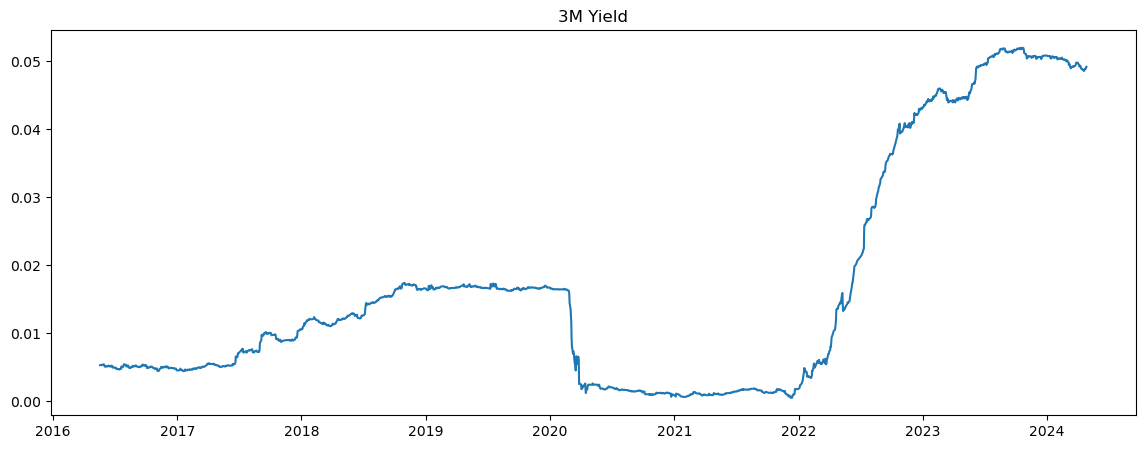

In [15]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["ZC025YR"])
#plt.axhline(y=0.0167, color='r', linestyle='-')
plt.title("3M Yield")
plt.show()

In [16]:
mean_r = df["ZC025YR"].mean()
std_r = df["ZC025YR"].std()

dr = df["ZC025YR"].diff().dropna()

mean_dr = dr.mean()
std_dr = dr.std()

print("Mean short rate =", mean_r)
print("Std short rate =", std_r)
print("Mean change =", mean_dr)
print("Std change =", std_dr)

Mean short rate = 0.016698838967611332
Std short rate = 0.016641625604911177
Mean change = 2.221908860759494e-05
Std change = 0.00023426106721810154


The 3-Month Treasury yield is used as the proxy for the short rate in the CIR framework.

The time-series plot shows multiple monetary policy regimes over the sample period. From 2016 to 2019, short rates gradually increased. In 2020, rates sharply declined following the COVID-19 crisis and remained near zero throughout 2020–2021. Beginning in 2022,rates increased rapidly due to aggressive monetary tightening and inflation-control policies.

The short-rate process therefore exhibits -

* strong regime dependence
* periods of prolonged low rates
* rapid upward adjustments during tightening cycles
* persistence and gradual mean-reverting behaviour
* economic shock
  
These characteristics motivate the use of stochastic short-rate models such as CIR.

---

## Summary Statistics

The sample mean short rate is

$$
\bar r = 0.01670
$$

with standard deviation

$$
\sigma_r = 0.01664
$$

The average daily change in rates is

$$
E[\Delta r_t] = 2.22\times10^{-5}
$$

while the standard deviation of changes is

$$
\sigma_{\Delta r} = 2.34\times10^{-4}
$$

The relatively small mean change compared to its volatility suggests that short-rate movements are dominated by stochastic fluctuations rather than deterministic drift over short horizons.

---

## Distribution of Short Rates

The boxplot indicates that the short-rate distribution is positively skewed with several upper-tail outliers corresponding to the high-rate environment observed during 2022–2024.

The lower bound remains close to zero throughout the sample, which is consistent with one of the key motivations for the CIR model:

$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t},dW_t
$$

The square-root diffusion term ensures that volatility decreases as rates approach zero, helping preserve positivity of the short-rate process.

---

## Evidence of Mean Reversion

The short-rate series displays clear mean-reverting behaviour. Periods of elevated rates are followed by gradual stabilization, while near-zero environments eventually revert upward during tightening cycles.

This behaviour is economically consistent with central bank monetary policy, where interest rates tend to fluctuate around long-run macroeconomic targets rather than drifting indefinitely.

The CIR model captures this mechanism through the drift component

$$
\kappa(\theta-r_t)
$$

where:

* $\kappa$ controls the speed of mean reversion
* $\theta$ represents the long-run equilibrium short rate



## Possible drawbacks of using CIR for this data

The CIR model satisfies strict positivity when the Feller condition holds:

$$
2\kappa\theta > \sigma^2
$$

This condition ensures that the short-rate process remains strictly positive and does not hit zero.

In practice, the Feller condition is most likely to break down during prolonged low-interest-rate or crisis environments. During such periods:

* the long-run mean $\theta$ becomes very small
* volatility $\sigma$ increases significantly
* mean reversion $\kappa$ may weaken due to persistent accommodative monetary policy

As a result, the left-hand side

$$
2\kappa\theta
$$

can become smaller than

$$
\sigma^2
$$

causing the Feller condition to fail.

This behaviour is commonly observed during:

* near-zero interest-rate regimes
* quantitative easing periods
* financial crises
* pandemic-era monetary interventions

For example, during 2020–2021, short rates remained extremely low while market uncertainty remained elevated. In such environments, CIR calibration may produce parameter estimates that violate the positivity condition.

When the Feller condition breaks down, the CIR process may approach zero, leading to:

* weaker economic interpretation
* numerical instability
* reduced accuracy of transition-density approximations
* difficulty in simulating paths near the zero lower bound




<Axes: >

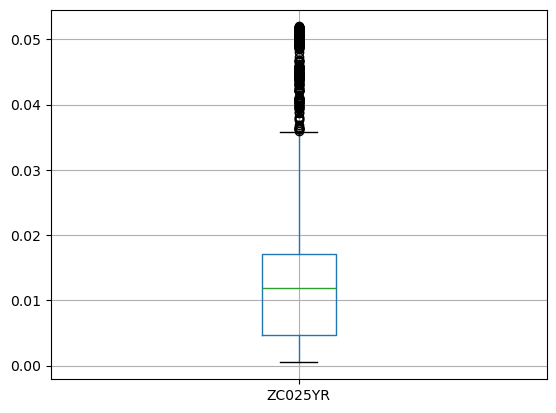

In [17]:
df[["ZC025YR"]].boxplot()

# Calibration of CIR parameters


## By OLS

###  CIR 

The CIR short rate process is defined by the stochastic differential equation

$$ dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t},dW_t $$

where:

* $r_t$ is the short rate
* $\kappa$ is the speed of mean reversion
* $\theta$ is the long-run mean
* $\sigma$ is the volatility parameter
* $dW_t$ is the Brownian motion increment

The drift term

$$ \kappa(\theta-r_t) $$

forces the process to revert toward the long-run mean $\theta$.

The diffusion term

$$ \sigma\sqrt{r_t} $$

makes volatility proportional to the square root of the interest rate.

---

To estimate the parameters using discrete data, we first discretize the CIR stochastic differential equation using Euler discretization:

$$ r_{t+1}-r_t = \kappa(\theta-r_t)\Delta t + \sigma\sqrt{r_t},\epsilon_t\sqrt{\Delta t} $$

where

$$ \epsilon_t \sim N(0,1) $$

Define the change in interest rates as

$$ \Delta r_t = r_{t+1}-r_t $$

Substituting this into the discretized CIR equation gives

$$ \Delta r_t = \kappa(\theta-r_t)\Delta t + \sigma\sqrt{r_t},\epsilon_t\sqrt{\Delta t} $$

---

To transform the equation into a linear regression form, divide both sides by (\sqrt{r_t}):

$$ \frac{\Delta r_t}{\sqrt{r_t}} = \kappa\theta\frac{\Delta t}{\sqrt{r_t}} - \kappa\Delta t\sqrt{r_t} + \sigma\epsilon_t\sqrt{\Delta t} $$

Define the dependent variable:

$$ y_t = \frac{\Delta r_t}{\sqrt{r_t}} $$

Define the regressors:

$$ x_{1,t} = \frac{\Delta t}{\sqrt{r_t}} $$

$$ x_{2,t} = \Delta t\sqrt{r_t} $$

The transformed equation becomes

$$ y_t = \beta_1 x_{1,t} + \beta_2 x_{2,t} + \varepsilon_t $$

where

$$ \beta_1 = \kappa\theta $$

and

$$ \beta_2 = -\kappa $$

This is now a standard linear regression problem.

---

In matrix form, the regression model is written as

$$ y = X\beta + \varepsilon $$

where:

* (y) is the vector of observations
* (X) is the matrix of regressors
* (\beta) is the vector of unknown parameters
* (\varepsilon) is the error vector

The Ordinary Least Squares (OLS) method estimates (\beta) by minimizing the sum of squared residuals:

$$ S(\beta)=\varepsilon^T\varepsilon $$

Since

$$ \varepsilon = y-X\beta $$

we obtain

$$ S(\beta)=(y-X\beta)^T(y-X\beta) $$

Expanding the quadratic expression:

$$ S(\beta)=y^Ty-2\beta^TX^Ty+\beta^TX^TX\beta $$

To minimize this function, differentiate with respect to (\beta):

$$ \frac{\partial S(\beta)}{\partial\beta}=-2X^Ty + 2X^TX\beta $$

Setting the derivative equal to zero gives

$$ -2X^Ty + 2X^TX\beta = 0 $$

which simplifies to the normal equation

$$ X^TX\beta = X^Ty $$

Multiplying both sides by ((X^TX)^{-1}) gives the OLS estimator:

$$ \hat{\beta} = (X^TX)^{-1}X^Ty $$

---

After estimating the regression coefficients, the CIR parameters are recovered using

$$ \kappa = -\beta_2 $$

and

$$ \theta = \frac{\beta_1}{\kappa} $$

---

The regression residuals are computed as

$$ \hat{\varepsilon}_t = y_t - X_t\hat{\beta} $$

From the transformed CIR equation,

$$ \hat{\varepsilon}_t = \sigma\epsilon_t\sqrt{\Delta t} $$

Taking variance on both sides:

$$ Var(\hat{\varepsilon}_t)=\sigma^2\Delta t $$

Therefore, the volatility estimate is

$$ \sigma=\sqrt{\frac{Var(\hat{\varepsilon}_t)}{\Delta t}} $$


In [18]:
from scipy.stats import ncx2
from scipy.optimize import minimize


# SHORT RATE SERIES
# -------------------------------------------------

# 3M yield used as proxy for short rate

r = df["ZC025YR"].values

# consecutive observations

r_t = r[:-1]

r_next = r[1:]

N = len(r)

print("Number of observations =", N)


# OLS INITIAL ESTIMATES
#----------------------------


dr = r_next - r_t

# dependent variable

y = dr / np.sqrt(r_t)

# regressors

X = np.column_stack([dt / np.sqrt(r_t),dt * np.sqrt(r_t)])

# OLS regression

beta = np.linalg.lstsq(X,y,rcond=None)[0]

# recover CIR parameters

kappa_init = -beta[1]

theta_init = beta[0] / kappa_init

# residuals

residuals = y - X @ beta

# volatility estimate

sigma_init = np.sqrt(np.var(residuals) / dt)

# positivity protection

kappa = abs(kappa_init)

theta = abs(theta_init)

sigma = abs(sigma_init)

print("\n===== OLS INITIAL ESTIMATES =====\n")

print("kappa=",kappa)

print("theta=",theta)

print("sigma=",sigma)


    



Number of observations = 1976

===== OLS INITIAL ESTIMATES =====

kappa= 0.25143190131557225
theta= 0.005292029383914232
sigma= 0.04104345062651536


The Feller condition

$$ 2\kappa\theta > \sigma^2 $$

Using the OLS estimates:

$$ 2(0.2514)(0.00529)=0.00266 $$

and

$$ (0.0410)^2=0.00168 $$

Since

$$ 0.00266 > 0.00168 $$

the Feller condition holds for this calibration. This implies that the CIR process remains strictly positive and avoids hitting zero.

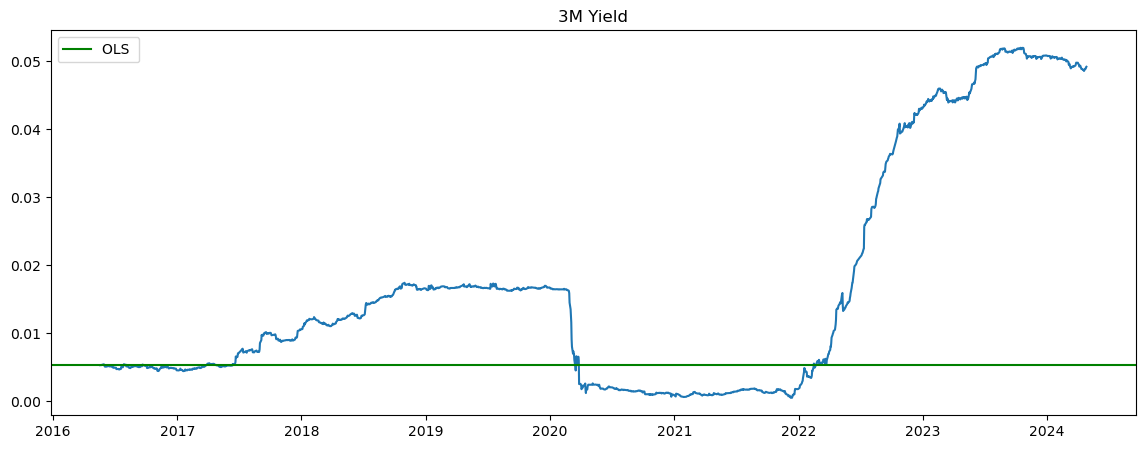

In [19]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["ZC025YR"])

plt.axhline(y= 0.005292029383914244, color='g', linestyle='-', label='OLS ')

plt.title("3M Yield")
plt.legend()
plt.show()


===== R² SCORES =====

ZC050YR      : 0.9769
ZC075YR      : 0.9476
ZC100YR      : 0.9058
ZC200YR      : 0.8409
ZC500YR      : 0.4403
ZC1000YR     : -0.8111
ZC2000YR     : -4.0994
ZC3000YR     : -5.3748

===== OVERALL R² =====

0.3866163182151503


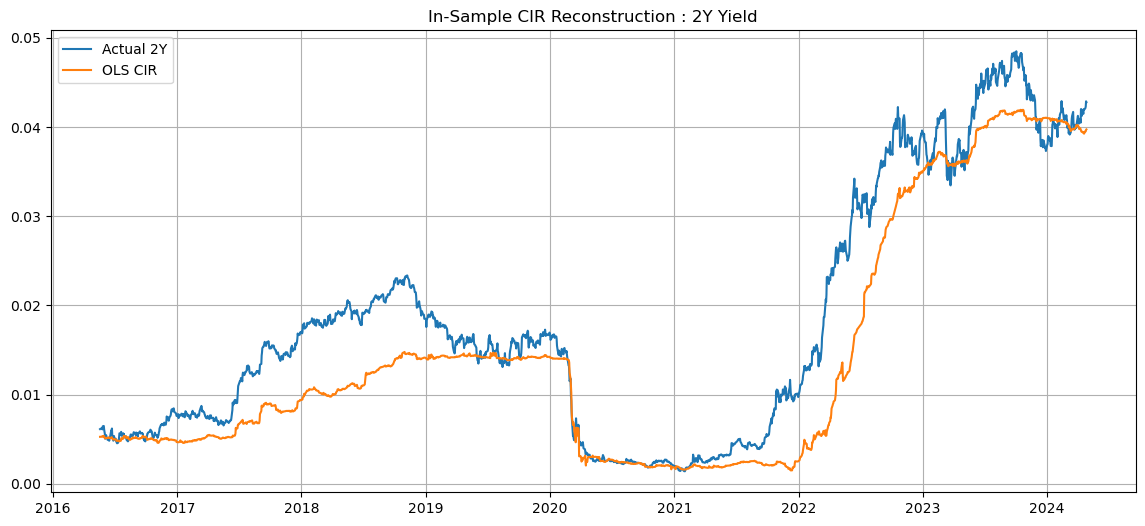

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

In [20]:
from sklearn.metrics import r2_score
# OLS PARAMETERS
# ---------------------------------------------------
kappa_ols = 0.2514319013155723

theta_ols = 0.005292029383914244

sigma_ols = 0.04104345062651536


# CIR FUNCTIONS
# --------------------------------------------------------
def cir_gamma(kappa, sigma):

    return np.sqrt(kappa**2 + 2*sigma**2)

# ---------------------------------------------------------

def B_tau(tau, kappa, sigma):

    gamma = cir_gamma(kappa,sigma)

    numerator = (2*(np.exp(gamma*tau) - 1))

    denominator = ((gamma + kappa)*(np.exp(gamma*tau) - 1)+2*gamma)

    return numerator / denominator

# ---------------------------------------------------------

def A_tau(tau,kappa,theta,sigma):

    gamma = cir_gamma(kappa,sigma)

    numerator = (2*gamma*np.exp((kappa + gamma)*tau/2))

    denominator = ((gamma + kappa)*(np.exp(gamma*tau) - 1)+2*gamma)

    power = (2*kappa*theta) / (sigma**2)

    return (numerator / denominator) ** power

# ---------------------------------------------------------

def cir_bond_price(rt,tau,kappa,theta,sigma):

    A = A_tau(tau,kappa,theta,sigma)

    B = B_tau(tau,kappa,sigma)

    return A * np.exp(-B * rt)

# ---------------------------------------------------------

def cir_yield(rt,tau,kappa,theta,sigma):

    P = cir_bond_price(rt,tau,kappa,theta,sigma)

    return -np.log(P) / tau


# MATURITY STRUCTURE
# ------------------------------------------------------------

maturity_map = {

    "ZC050YR":0.50,
    "ZC075YR":0.75,
    "ZC100YR":1.00,
    "ZC200YR":2.00,
    "ZC500YR":5.00,
    "ZC1000YR":10.00,
    "ZC2000YR":20.00,
    "ZC3000YR":30.00

}


# GENERATE PREDICTIONS
# -------------------------------------------------------------------

predictions_ols = []

for i in range(len(df)):

    rt = df.loc[i, "ZC025YR"]

    row_ols = {}

    # save date

    row_ols["Date"] = df.loc[i, "Date"]

    
    # EACH MATURITY
    # -----------------------------------------------------

    for col, tau in maturity_map.items():

        y_ols = cir_yield(rt,tau,kappa_ols,theta_ols,sigma_ols)

        row_ols[col] = y_ols

   
    predictions_ols.append(row_ols)


# DATAFRAME
# ------------------------------------------------------------
pred_ols_df = pd.DataFrame(predictions_ols)


# R² SCORES
# ---------------------------------------------------------

print("\n===== R² SCORES =====\n")

actual_all = []

pred_all = []

for col in maturity_map.keys():

    actual = df[col]

    pred_ols = pred_ols_df[col]

    r2_ols = r2_score(actual,pred_ols)

    print(f"{col:<12} : {r2_ols:.4f}")

    actual_all.extend(actual.values)

    pred_all.extend(pred_ols.values)


# OVERALL R²
# ------------------------------------------------------------

overall_r2 = r2_score(np.array(actual_all),np.array(pred_all))

print("\n===== OVERALL R² =====\n")

print(overall_r2)


# VISUALIZATION
# ---------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(df["Date"],df["ZC200YR"],label="Actual 2Y")

plt.plot(pred_ols_df["Date"],pred_ols_df["ZC200YR"],label="OLS CIR")

plt.legend()

plt.title("In-Sample CIR Reconstruction : 2Y Yield")

plt.grid(True)

plt.show()

plt.figure(figsize=(14,6))


### Why the OLS CIR Reconstruction Performs Poorly

Although the CIR model captures the broad direction of the 2Y yield, the fitted curve is excessively smooth compared to the observed market data. This explains the relatively weak overall in-sample performance:

$$ R^2 = 0.3866 $$

Several issues are visible directly from the reconstruction plot.

* The model reacts too slowly during the sharp tightening cycle of 2022–2023. Observed yields rise rapidly, while the CIR reconstruction adjusts gradually.

* The fitted curve underestimates both the magnitude and speed of large market moves. This occurs because the estimated mean-reversion speed

$$ \kappa = 0.2514 $$

is relatively low, implying persistent shocks and slow adjustment toward equilibrium.

* The CIR model assumes constant parameters throughout the entire sample, but the dataset contains multiple monetary policy regimes:

  * low-rate regime during 2020–2021
  * aggressive tightening during 2022–2024

A single constant-parameter model cannot simultaneously fit both environment.

* OLS calibration uses the Euler approximation rather than the exact transition density, introducing discretization error and reducing estimation accuracy during volatile periods.

* The one-factor CIR structure also forces the yield curve to move primarily through the short rate. As a result, long-end yield dynamics and curve curvature are not captured effectively.

Overall, the reconstruction shows that the CIR model captures long-run trends reasonably well but struggles with rapid regime changes, volatility spikes, and higher-frequency market movements.


# Calibration via MLE

## CIR Transition Density

From the CIR paper, the exact transition density is

$$ f(r(s),s;r(t),t)=ce^{-u-v}\left(\frac{v}{u}\right)^{q/2}I_q\left(2\sqrt{uv}\right) $$

where

$$ c=\frac{2\kappa}{\sigma^2(1-e^{-\kappa(s-t)})} $$

$$ u=cr(t)e^{-\kappa(s-t)} $$

$$ v=cr(s) $$

$$ q=\frac{2\kappa\theta}{\sigma^2}-1 $$

---

## Transformation to Non-Central Chi-Square Form

Define

$$ x=2v $$

Since

$$ v=cr(s) $$

we obtain

$$ x=2cr(s) $$

Also define

$$ \lambda=2u $$

Substituting for $u$:

$$ \lambda=2cr(t)e^{-\kappa(s-t)} $$

Define

$$ d=\frac{4\kappa\theta}{\sigma^2} $$

Using

$$ q=\frac{2\kappa\theta}{\sigma^2}-1 $$

we get

$$ q=\frac{d}{2}-1 $$

Substituting these expressions into the CIR density:

$$ f(r(s),s;r(t),t)=ce^{-(x+\lambda)/2}\left(\frac{x}{\lambda}\right)^{q/2}I_q(\sqrt{\lambda x}) $$

The non-central chi-square density is

$$ f_{\chi'^2}(x;d,\lambda)=\frac12 e^{-(x+\lambda)/2}\left(\frac{x}{\lambda}\right)^{d/4-1/2}I_{d/2-1}(\sqrt{\lambda x}) $$

Since

$$ q=\frac{d}{2}-1 $$

the CIR density matches the non-central chi-square density.

Hence,

$$ 2cr_{t+\Delta t}\sim\chi'^2(d,\lambda) $$

where

$$ d=\frac{4\kappa\theta}{\sigma^2} $$

and

$$ \lambda=2cr_te^{-\kappa\Delta t} $$

---

## Transition Density Used in MLE

Define

$$ s=2cr_{t+\Delta t} $$

Then

$$ s\sim\chi'^2(d,\lambda) $$

Using the change-of-variable formula:

$$ f_r(r)=f_s(s)\left|\frac{ds}{dr}\right| $$

Since

$$ \frac{ds}{dr}=2c $$

the CIR transition density becomes

$$ f_r(r)=f_{\chi'^2}(2cr;d,\lambda)\cdot 2c $$

Taking logarithms:

$$ \log f_r(r)=\log f_{\chi'^2}(2cr;d,\lambda)+\log(2c) $$

---

## Likelihood Function

For observations

$$ r_1,r_2,\dots,r_N $$

the likelihood function is

$$ \mathcal{L}(\kappa,\theta,\sigma)=\prod_{t=1}^{N-1}f(r_{t+1}\mid r_t) $$

Taking logarithms:

$$ \log\mathcal{L}=\sum_{t=1}^{N-1}\log f(r_{t+1}\mid r_t) $$

Substituting the CIR transition density:

$$ \log\mathcal{L}=\sum_{t=1}^{N-1}\left[\log f_{\chi'^2}(2cr_{t+1};d,\lambda)+\log(2c)\right] $$

The MLE estimator is

$$ (\hat{\kappa},\hat{\theta},\hat{\sigma})=\arg\max_{\kappa,\theta,\sigma}\log\mathcal{L} $$

Equivalently,

$$ (\hat{\kappa},\hat{\theta},\hat{\sigma})=\arg\min_{\kappa,\theta,\sigma}(-\log\mathcal{L}) $$


In [21]:
from scipy.optimize import differential_evolution


# SHORT RATE SERIES
# ---------------------------------------------------

r = df["ZC025YR"].values


# OBSERVATIONS
#-------------------------------------------------------

r_t = r[:-1]

r_next = r[1:]

# NEGATIVE LOG-LIKELIHOOD
# --------------------------------------------------------
def neg_log_likelihood(params):

    kappa, theta, sigma = params

    
    # POSITIVITY CONSTRAINTS
    # -----------------------------------------------------

    if (kappa <= 0 or theta <= 0 or sigma <= 0):
        return 1e10

    try:

        s2 = sigma**2

       
        # EXPONENTIAL TERM
        exp_k = np.exp(-kappa * dt)

       
        # CIR CONSTANT
        # -------------------------------------------------

        c = (2 * kappa) / (s2*(1 - exp_k))

        
        # DEGREES OF FREEDOM
        # -------------------------------------------------

        df_chi = (4 * kappa * theta) / s2

        # invalid region protection

        if df_chi <= 0:
            return 1e10

        
        # NON-CENTRALITY PARAMETER
        # -------------------------------------------------

        nc = (2*c*r_t*exp_k)

        
        # TRANSFORMED OBSERVATIONS
        # -------------------------------------------------

        s = (2*c*r_next)

        
        # NUMERICAL STABILITY
        # -------------------------------------------------

        nc = np.maximum(nc,1e-12)

        s = np.maximum(s,1e-12)

        
        # NON-CENTRAL CHI-SQUARE LOG DENSITY

        logpdf = ncx2.logpdf(s,df=df_chi,nc=nc)

        
        # CIR TRANSITION DENSITY

        logpdf = logpdf + np.log(2*c)

        # remove invalid entries

        logpdf = logpdf[np.isfinite(logpdf)]

       
        # NEGATIVE LOG-LIKELIHOOD

        return -np.sum(logpdf)

    except:

        return 1e10


# PARAMETER SEARCH RANGES
r_mean = np.mean(r)

r_std = np.std(r)

bounds = [(1e-4, 15.0),(max(1e-5,r_mean - 4*r_std),r_mean + 4*r_std),(1e-5, 0.5)]

# OPTIMIZATION
print("\n===== STARTING EXACT CIR MLE =====\n")

result = differential_evolution(neg_log_likelihood,bounds=bounds,seed=42,maxiter=2000,tol=1e-12,polish=True)


# ESTIMATED PARAMETERS
kappa_hat, theta_hat, sigma_hat = result.x

print("\n===== CIR MLE ESTIMATES =====\n")

print("kappa =", kappa_hat)

print("theta =", theta_hat)

print("sigma =", sigma_hat)


# FELLER CONDITION
print("\n===== FELLER CONDITION =====\n")

print("2*kappa*theta > sigma^2 :",2*kappa_hat*theta_hat > sigma_hat**2)

print("LHS =",2*kappa_hat*theta_hat)

print("RHS =",sigma_hat**2)





===== STARTING EXACT CIR MLE =====


===== CIR MLE ESTIMATES =====

kappa = 0.023100738980242636
theta = 0.08324849535850978
sigma = 0.04229915647937329

===== FELLER CONDITION =====

2*kappa*theta > sigma^2 : True
LHS = 0.0038462035235497503
RHS = 0.0017892186388665072


In [22]:
theta_lower = max(1e-5, r_mean - 4*r_std)

theta_upper = r_mean + 4*r_std

print("Theta lower bound =", theta_lower)

print("Theta upper bound =", theta_upper)

Theta lower bound = 1e-05
Theta upper bound = 0.08324849550506305



===== IN-SAMPLE TESTING =====

Maturity              R²
------------------------
ZC050YR           0.9911
ZC075YR           0.9776
ZC100YR           0.9570
ZC200YR           0.8660
ZC500YR           0.4139
ZC1000YR         -0.0153
ZC2000YR         -0.7008
ZC3000YR         -1.7262

===== OVERALL IN-SAMPLE R² =====

0.7042175698581998


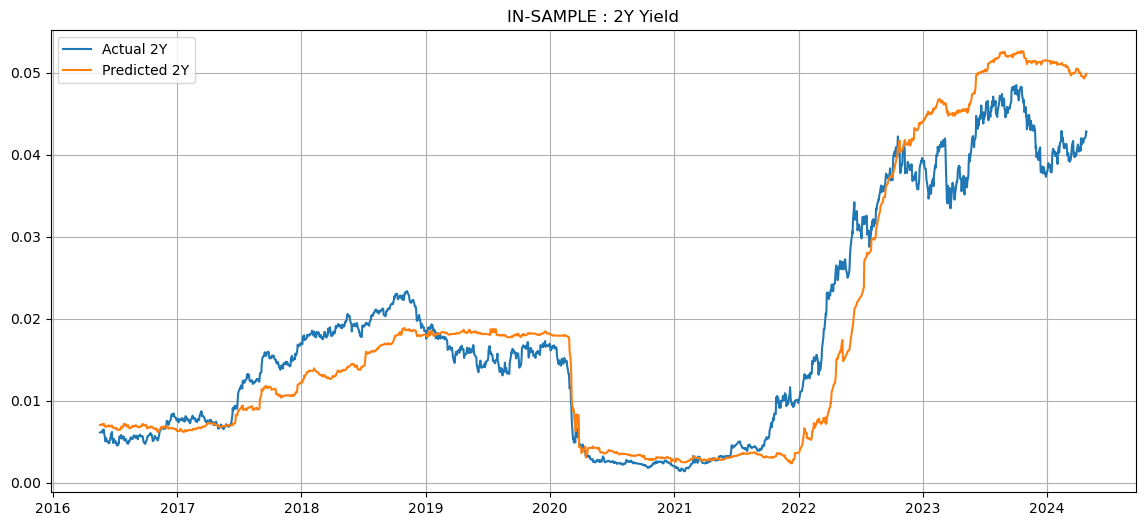

In [23]:
# GLOBAL MLE PARAMETERS
# --------------------------------------------------------

kappa = 0.02341097724447832

theta = 0.08324849546718593

sigma = 0.04258200527194655

# CIR FUNCTIONS
# -----------------------------------------------------

def cir_gamma(kappa, sigma):

    return np.sqrt(kappa**2 + 2*sigma**2)

# ---------------------------------------------------------

def B_tau(tau,kappa,sigma):

    gamma = cir_gamma(kappa,sigma)

    numerator = (2*(np.exp(gamma*tau)-1))

    denominator = ((gamma+kappa)*(np.exp(gamma*tau)-1)+2*gamma)

    return numerator / denominator

# ---------------------------------------------------------

def A_tau(tau,kappa,theta,sigma):

    gamma = cir_gamma(kappa,sigma)

    numerator = (2*gamma*np.exp((kappa+gamma)*tau/2))

    denominator = ((gamma+kappa)*(np.exp(gamma*tau)-1)+2*gamma)

    power = (2*kappa*theta) / (sigma**2)

    return (numerator / denominator) ** power

# ---------------------------------------------------------

def cir_bond_price(rt,tau):

    A = A_tau(tau,kappa,theta,sigma)

    B = B_tau(tau,kappa,sigma)

    return A * np.exp(-B*rt)

# ---------------------------------------------------------

def cir_yield(rt,tau):

    P = cir_bond_price(rt,tau)

    return -np.log(P) / tau




# IN-SAMPLE TESTING
# -------------------------------------------------------------

print("\n===== IN-SAMPLE TESTING =====\n")

# =========================================================
# GENERATE PREDICTIONS
# =========================================================

insample_predictions = []

for i in range(len(df)):

    rt = df.iloc[i]["ZC025YR"]

    row = {"Date": df.iloc[i]["Date"]}

    for col, tau in maturity_map.items():

        row[col] = cir_yield(
            rt,
            tau
        )

    insample_predictions.append(row)


# PREDICTION DATAFRAME
# ------------------------------------------------

insample_pred_df = pd.DataFrame(insample_predictions)


# R² SCORES
# ----------------------------------------------

print(

    f"{'Maturity':<12}"

    f"{'R²':>12}"

)

print("-"*24)

actual_all = []

pred_all = []

for col in maturity_map.keys():

    actual = df[col]

    predicted = insample_pred_df[col]

    r2 = r2_score(actual,predicted)

    print(
        f"{col:<12}"

        f"{r2:>12.4f}"

    )

    actual_all.extend(actual.values)

    pred_all.extend(predicted.values)


# OVERALL R²
# -------------------------------------------------------

overall_r2 = r2_score(np.array(actual_all),np.array(pred_all))

print("\n===== OVERALL IN-SAMPLE R² =====\n")

print(overall_r2)


# IN-SAMPLE VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(df["Date"],df["ZC200YR"],label="Actual 2Y")

plt.plot(insample_pred_df["Date"],insample_pred_df["ZC200YR"],label="Predicted 2Y")

plt.legend()

plt.title("IN-SAMPLE : 2Y Yield")

plt.grid(True)

plt.show()



### Instability of Exact CIR MLE Calibration

The Exact MLE calibration produced the following estimates:

$$ \kappa = 0.0231 $$

$$ \theta = 0.08325 $$

$$ \sigma = 0.0423 $$

The estimated long-run mean

$$ \theta = 0.08325 $$

is effectively equal to the optimization upper bound:

$$ \theta_{\text{upper}} = 0.0832485 $$

This indicates that the optimizer pushed $$ \theta $$ to the maximum allowable value in order to improve the likelihood fit. Infact I tried to find its value without any bound and it reached to 0.8 and rendered feller condition false, all of which made no economical sense 

The main reason for this behaviour is the strong regime shift present in the dataset. The sample includes:

* near-zero interest rates during 2020–2021
* extremely rapid tightening during 2022–2024

Because the CIR model assumes constant parameters over the entire sample, the optimizer attempts to explain the high-rate regime by increasing the long-run equilibrium level $$ \theta $$.

At the same time, the estimated mean-reversion speed is extremely small:

$$ \kappa = 0.0231 $$

which implies very slow mean reversion and highly persistent shocks. This allows the model to maintain elevated rates for long periods after the 2022 tightening cycle.

This behaviour occurs because the likelihood optimization problem is highly unstable in the presence of strong regime changes and persistent trends in the data. The sample contains:

* near-zero rates during 2020–2021
* rapid monetary tightening during 2022–2024

To control this instability, practical parameter bounds were imposed during optimization. The upper bound on prevents the optimizer from drifting toward unrealistic equilibrium rate levels that are inconsistent with the observed yield environment.

# Direct Yield Curve fitting for calibration of CIR parameters



# Bond Pricing Solution

The CIR zero-coupon bond price takes the form

$$ P(r,t,T)=A(t,T)e^{-B(t,T)r_t} $$


The functions:

* $A(t,T)$
* $B(t,T)$

fully determine the shape of the yield curve.

---

# Market Price of Risk Parameter

In the original CIR paper, the bond pricing formulas include the market price of risk parameter $ \lambda $.

The general CIR quantity is

$$ \gamma = \sqrt{(\kappa+\lambda)^2+2\sigma^2} $$

and the bond pricing functions become

$$ B(t,T)=\frac{2(e^{\gamma(T-t)}-1)}{(\gamma+\kappa+\lambda)(e^{\gamma(T-t)}-1)+2\gamma} $$

and

$$ A(t,T)=\left[\frac{2\gamma e^{[(\kappa+\lambda+\gamma)(T-t)]/2}}{(\gamma+\kappa+\lambda)(e^{\gamma(T-t)}-1)+2\gamma}\right]^{\frac{2\kappa\theta}{\sigma^2}} $$

However, in this implementation the market price of risk was assumed to be zero (risk neutral pricing):

$$ \lambda = 0 $$



After setting

$$ \lambda = 0 $$

the CIR quantity simplifies to

$$ \gamma = \sqrt{\kappa^2+2\sigma^2} $$

which is the expression implemented in the code.

---

# CIR Duration Loading Function

Defining maturity as

$$ \tau = T-t $$

the CIR duration loading function becomes

$$ B(\tau)=\frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma} $$

The function $ B(\tau) $ measures the sensitivity of bond prices to movements in the short rate.

For larger maturities, the influence of long-run mean reversion becomes stronger.

---

# CIR Scaling Function

The CIR scaling function becomes

$$ A(\tau)=\left[\frac{2\gamma e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right]^{\frac{2\kappa\theta}{\sigma^2}} $$

This component incorporates:

* long-run equilibrium behaviour
* volatility effects
* mean-reversion structure

into the bond price.

The exponent

$$ \frac{2\kappa\theta}{\sigma^2} $$

plays an important role in determining the long-run shape of the term structure.

---

# CIR Bond Price Formula

After computing $ A(\tau) $ and $ B(\tau) $, the zero-coupon bond price becomes

$$ P(t,\tau)=A(\tau)e^{-B(\tau)r_t} $$

For every observation date:

1. the observed 3M Treasury yield was treated as the short rate $ r_t $
2. the CIR analytical formulas were evaluated
3. theoretical zero-coupon bond prices were generated

Thus, a single short-rate observation generates an entire theoretical yield curve.

---

# Conversion from Bond Prices to Yields

The continuously compounded yield satisfies

$$ P(t,\tau)=e^{-\tau y(t,\tau)} $$

Taking logarithms gives the CIR-implied yield:

$$ y(t,\tau)=-\frac{\log P(t,\tau)}{\tau} $$

This converts theoretical bond prices into model-implied yields.

For each maturity and each observation date, the model therefore produces

$$ y^{\text{CIR}}(t,\tau) $$

which can be directly compared against observed market yields.

---

# Yield Curve Reconstruction

Using the observed short rate $ r_t $, CIR-implied yields were generated for the maturities:

$$ 0.5,\ 0.75,\ 1,\ 2,\ 5,\ 10,\ 20,\ 30 $$

years.

For every date in the sample, this produced a complete theoretical CIR yield curve.

The calibration problem therefore becomes:

> find the CIR parameters that produce the yield curve closest to the observed Treasury term structure.

---

# Calibration via MSE Function

For each maturity and observation date, the fitting error was computed as

$$ \text{Error}=y^{\text{actual}}-y^{\text{CIR}} $$

The total fitting error across the entire dataset was measured using the Mean Squared Error (MSE):

$$ \text{MSE}=\frac1N\sum_{i=1}^{N}(y_i^{\text{actual}}-y_i^{\text{CIR}})^2 $$

where:

* $y_i^{\text{actual}}$ are observed Treasury yields
* $y_i^{\text{CIR}}$ are model-implied CIR yields

Smaller values of MSE imply a closer fit between the CIR yield curve and the observed market yield curve.

---

# Optimization Problem

The calibration objective becomes

$$ (\hat\kappa,\hat\theta,\hat\sigma)=\arg\min_{\kappa,\theta,\sigma}\text{MSE} $$

The optimizer repeatedly:

1. guesses CIR parameters
2. constructs the theoretical yield curve
3. computes the fitting error
4. updates the parameters
5. searches for the parameter set minimizing MSE

This procedure directly calibrates the CIR model to the observed Treasury yield curve rather than only fitting short-rate dynamics.

---

# Constrained Optimization

The optimization was performed using the L-BFGS-B algorithm with positivity constraints:

$$ \kappa>0,\quad \theta>0,\quad \sigma>0 $$

The parameter bounds used were:

$$ 10^{-5}\le\kappa\le5 $$

$$ 10^{-5}\le\theta\le1 $$

$$ 10^{-5}\le\sigma\le1 $$

These constraints prevent:

* negative parameters
* numerical instability
* unrealistic parameter explosions

during optimization.

---

# In-Sample Evaluation

After calibration, the CIR-implied yields were compared against observed yields using the coefficient of determination:

$$ R^2=1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2} $$

Higher values of $R^2$ indicate better reconstruction accuracy.

The model achieved reasonable performance for short maturities but weaker performance for long maturities, highlighting a major limitation of the one-factor CIR framework:

a single short-rate factor cannot fully explain the level, slope, and curvature of the entire yield curve simultaneously.



===== INITIAL GUESS =====

kappa = 0.05
theta = 0.05
sigma = 0.03

===== STARTING DIRECT YIELD FIT =====


===== OPTIMAL PARAMETERS =====

kappa = 0.15006199463556896
theta = 0.026888765482306714
sigma = 0.08166089004918596

===== FELLER CONDITION =====

2*kappa*theta > sigma^2 : True
LHS = 0.008069963563125964
RHS = 0.006668500963625239

===== IN-SAMPLE R² =====

ZC050YR      : 0.9895
ZC075YR      : 0.9751
ZC100YR      : 0.9535
ZC200YR      : 0.9110
ZC500YR      : 0.7586
ZC1000YR     : 0.7222
ZC2000YR     : 0.6302
ZC3000YR     : 0.5507

===== OVERALL R² =====

0.905707757924626


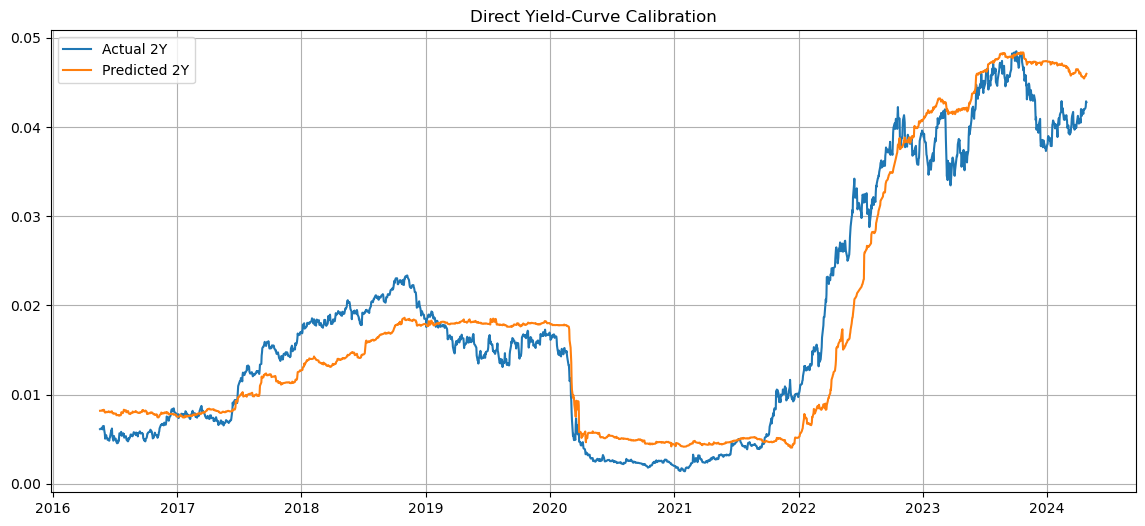

In [24]:
# SHORT RATE
# ----------------------------------------------------------

r_short = df["ZC025YR"].values

# CIR FUNCTIONS
# -----------------------------------------------------------
def gamma_cir( kappa, sigma):

    return np.sqrt(kappa**2 + 2*sigma**2)

# ---------------------------------------------------------

def B_tau(tau,kappa,sigma):

    g = gamma_cir(kappa,sigma)

    num = (2*(np.exp(g*tau)-1))

    den = ((g+kappa)*(np.exp(g*tau)-1)+2*g)

    return num/den

# ---------------------------------------------------------

def A_tau(tau,kappa,theta,sigma):

    g = gamma_cir(kappa,sigma)

    num = (2*g*np.exp((kappa+g)*tau/2))

    den = ((g+kappa)*(np.exp(g*tau)-1)+2*g)

    power = (2*kappa*theta) / (sigma**2)

    return (num/den)**power

# ---------------------------------------------------------

def cir_bond_price(rt,tau,kappa,theta,sigma):

    A = A_tau(tau,kappa,theta,sigma)

    B = B_tau(tau,kappa,sigma)

    return A * np.exp(-B*rt)

# ---------------------------------------------------------

def cir_yield(rt,tau,kappa,theta,sigma):

    P = cir_bond_price(rt,tau,kappa,theta,sigma)

    return -np.log(P) / tau


# LOSS FUNCTION
# -------------------------------------------------

def objective(params):

    kappa, theta, sigma = params

    # positivity protection

    if (
        kappa <= 0
        or theta <= 0
        or sigma <= 0
    ):
        return 1e10

    try:

        actual_all = []

        pred_all = []

        
        # ENTIRE YIELD CURVE
        # -------------------------------------------------

        for col, tau in maturity_map.items():

            actual = df[col].values

            predicted = []

            for i in range(len(df)):

                rt = r_short[i]

                y_hat = cir_yield(rt,tau,kappa,theta,sigma)

                predicted.append(y_hat)

            predicted = np.array(predicted)

            actual_all.extend(actual)

            pred_all.extend(predicted)

        actual_all = np.array(actual_all)

        pred_all = np.array(pred_all)

        
        # MSE LOSS
        # -------------------------------------------------

        mse = np.mean((actual_all - pred_all)**2)

        return mse

    except:

        return 1e10


# INITIAL GUESS
# ---------------------------------------------------------
initial_guess = [

    0.05,    # kappa
    0.05,    # theta
    0.03     # sigma

]

print("\n===== INITIAL GUESS =====\n")

print("kappa =", initial_guess[0])

print("theta =", initial_guess[1])

print("sigma =", initial_guess[2])


# OPTIMIZATION
# ------------------------------------------------

print("\n===== STARTING DIRECT YIELD FIT =====\n")

result = minimize(objective,initial_guess,method="L-BFGS-B",

    bounds=[

        (1e-5,5),      # kappa

        (1e-5,1),      # theta

        (1e-5,1)       # sigma

    ]

)


# OPTIMAL PARAMETERS
# -------------------------------------------------------------
kappa_opt, theta_opt, sigma_opt = result.x

print("\n===== OPTIMAL PARAMETERS =====\n")

print("kappa =", kappa_opt)

print("theta =", theta_opt)

print("sigma =", sigma_opt)


# FELLER CONDITION
# -------------------------------------------------------------
print("\n===== FELLER CONDITION =====\n")

print("2*kappa*theta > sigma^2 :",2*kappa_opt*theta_opt > sigma_opt**2)

print("LHS =",2*kappa_opt*theta_opt)

print("RHS =",sigma_opt**2)


# GENERATE FITTED YIELDS
# --------------------------------------------------
predictions = []

for i in range(len(df)):

    rt = r_short[i]

    row = {

        "Date": df.loc[i, "Date"]

    }

    for col, tau in maturity_map.items():

        row[col] = cir_yield(

            rt,
            tau,

            kappa_opt,
            theta_opt,
            sigma_opt

        )

    predictions.append(row)

pred_df = pd.DataFrame(predictions)


# R² SCORES
#-----------------------------------------------

print("\n===== IN-SAMPLE R² =====\n")

actual_all = []

pred_all = []

for col in maturity_map.keys():

    r2 = r2_score(df[col],pred_df[col])

    print(f"{col:<12} : {r2:.4f}")

    actual_all.extend(df[col].values)

    pred_all.extend(pred_df[col].values)

overall_r2 = r2_score(np.array(actual_all),np.array(pred_all))

print("\n===== OVERALL R² =====\n")

print(overall_r2)


# VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(14,6))

plt.plot(df["Date"],df["ZC200YR"],label="Actual 2Y")

plt.plot(pred_df["Date"],pred_df["ZC200YR"],label="Predicted 2Y")

plt.legend()

plt.title("Direct Yield-Curve Calibration")

plt.grid(True)

plt.show()





===== OUT-OF-SAMPLE R² =====

ZC050YR      : 0.9935
ZC075YR      : 0.9632
ZC100YR      : 0.9003
ZC200YR      : 0.3407

===== OVERALL OUT-OF-SAMPLE R² =====

0.8831947323212536


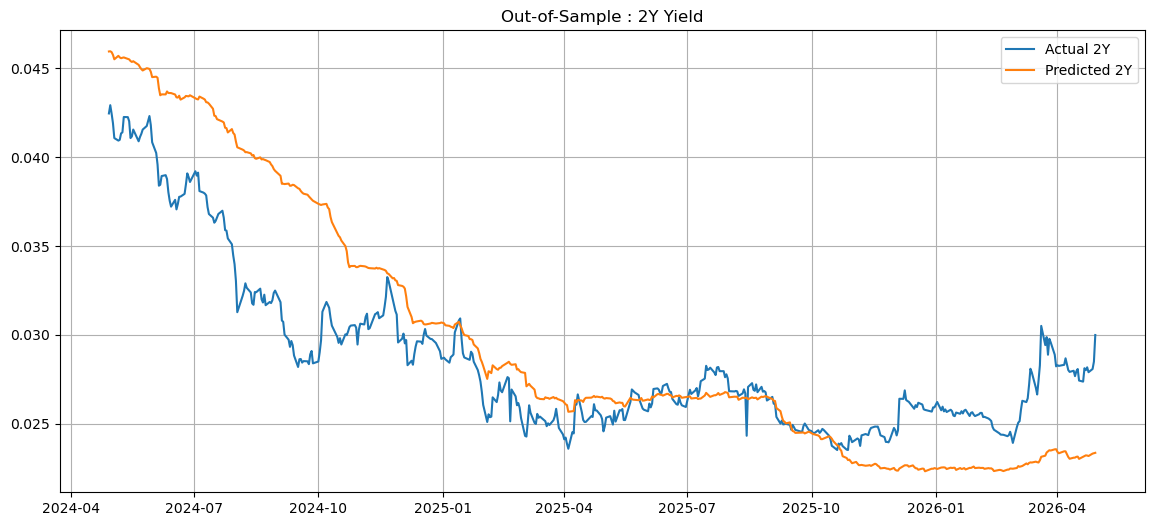

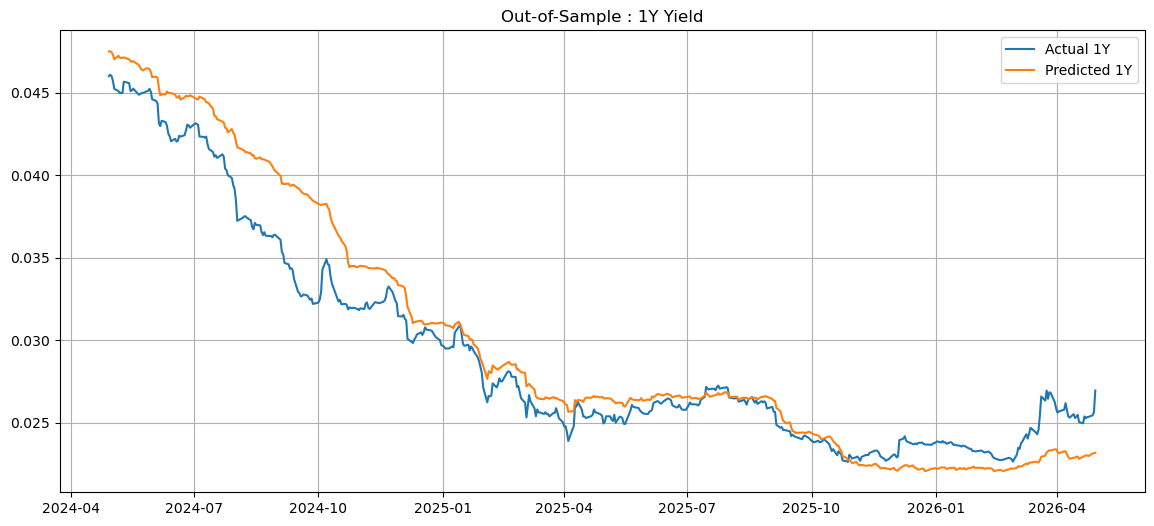

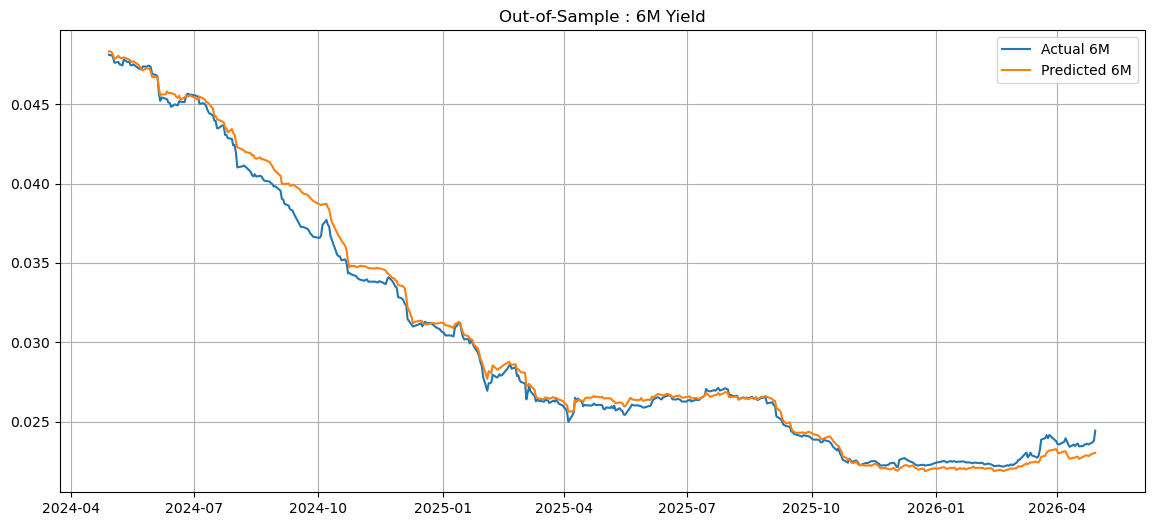

In [25]:
# OUT-OF-SAMPLE TESTING
# =========================================================

from sklearn.metrics import r2_score


# LOAD TEST DATA
# ---------------------------------------------------------

test_curve = pd.read_csv(test_d)

test_3m = pd.read_csv(test_d3M)


# CLEAN COLUMN NAMES
# ------------------------------------------------------

test_curve.columns = test_curve.columns.str.strip()

test_3m.columns = test_3m.columns.str.strip()


# DATE PARSING
# ------------------------------------------------------------

test_curve["Date"] = pd.to_datetime(test_curve["Date"])

test_3m["Date"] = pd.to_datetime(test_3m["Date"])


# GENERATE PREDICTIONS
# -------------------------------------------------------------------------

predictions = []

for i in range(len(test_3m)):

    rt = test_3m.loc[i, "ZC025YR"]

    row = {"Date": test_3m.loc[i, "Date"]}

    for col, tau in maturity_map.items():



        if col in test_curve.columns:

            row[col] = cir_yield(rt,tau,kappa_opt,theta_opt,sigma_opt)

    predictions.append(row)


# PREDICTION DATAFRAME
# ------------------------------------------------------------

pred_df = pd.DataFrame(predictions)


# OUT-OF-SAMPLE R²
# -----------------------------------------------------------

print("\n===== OUT-OF-SAMPLE R² =====\n")

actual_all = []

pred_all = []

for col in pred_df.columns:

    if col == "Date":
        continue

    actual = test_curve[col]

    predicted = pred_df[col]

    r2 = r2_score(actual,predicted)

    print(f"{col:<12} : {r2:.4f}")

    actual_all.extend(actual.values)

    pred_all.extend(predicted.values)


# OVERALL R²
# -----------------------------------------------------------
overall_r2 = r2_score(np.array(actual_all),np.array(pred_all))

print("\n===== OVERALL OUT-OF-SAMPLE R² =====\n")

print(overall_r2)


# VISUALIZATION : 2Y
# -----------------------------------------
if "ZC200YR" in pred_df.columns:

    plt.figure(figsize=(14,6))

    plt.plot(test_curve["Date"],test_curve["ZC200YR"], label="Actual 2Y")

    plt.plot(pred_df["Date"],pred_df["ZC200YR"],label="Predicted 2Y")

    plt.legend()

    plt.title("Out-of-Sample : 2Y Yield")

    plt.grid(True)

    plt.show()

# VISUALIZATION : 1Y
# ------------------------------------------------

if "ZC100YR" in pred_df.columns:

    plt.figure(figsize=(14,6))

    plt.plot(test_curve["Date"],test_curve["ZC100YR"],label="Actual 1Y")

    plt.plot(pred_df["Date"],pred_df["ZC100YR"],label="Predicted 1Y")

    plt.legend()

    plt.title("Out-of-Sample : 1Y Yield")
    plt.grid(True)

    plt.show()

# VISUALIZATION : 1Y
# -----------------------------------------------

if "ZC050YR" in pred_df.columns:

    plt.figure(figsize=(14,6))

    plt.plot(test_curve["Date"],test_curve["ZC050YR"],label="Actual 6M")

    plt.plot(pred_df["Date"],pred_df["ZC050YR"],label="Predicted 6M")

    plt.legend()

    plt.title("Out-of-Sample : 6M Yield")
    plt.grid(True)

    plt.show()

# Sensitivity of the Yield Curve to Calibration Methodology

The calibrated yield curve was highly sensitive to the chosen calibration methodology.

Earlier OLS-based short-rate calibration produced weak yield curve reconstruction performance with an overall in-sample

$$ R^2 \approx 0.39 $$

and strongly negative long-maturity $R^2$ values.

In contrast, direct yield-curve calibration significantly improved performance:

$$ R^2_{\text{in-sample}} = 0.9057 $$

and

$$ R^2_{\text{out-of-sample}} = 0.8832 $$

The improvement occurs because the direct calibration approach estimates the CIR parameters by minimizing the difference between observed and model-implied yields across the entire term structure, rather than only fitting short-rate dynamics.

OLS calibration primarily captures the time-series behaviour of the short rate, while direct yield fitting calibrates the model specifically for cross-sectional term-structure reconstruction.

This demonstrates that CIR parameter estimates are highly dependent on the calibration objective function. Parameters that explain short-rate evolution well do not necessarily generate an accurate yield curve.

---

# Interpretation of Mean-Reversion Speed 

The calibrated mean-reversion speed was

$$ \kappa = 0.1501 $$

This relatively small value implies slow mean reversion and persistent interest-rate shocks.

Under the CIR model, the drift component

$$ \kappa(\theta-r_t) $$

controls the speed at which rates revert toward the long-run equilibrium level.

A small value of $ \kappa $ means that deviations from equilibrium decay slowly over time. Consequently, shocks to interest rates remain persistent for extended periods before gradually reverting toward the long-run mean.

This behaviour is consistent with the dataset, which contains prolonged monetary policy regimes:

* near-zero interest rates during 2020–2021
* persistent tightening during 2022–2024

The relatively low value of $ \kappa $ therefore reflects the long persistence of monetary policy shocks observed in the Treasury yield data.

---

# Systematic Yield Curve Mispricing in the CIR Model

Although the direct yield calibration substantially improved overall performance, the CIR model still exhibits systematic fitting limitations.

The model fits short maturities extremely well:

* 6M: $R^2 = 0.9895$
* 1Y: $R^2 = 0.9535$
* 2Y: $R^2 = 0.9110$

However, performance gradually deteriorates for longer maturities:

* 10Y: $R^2 = 0.7222$
* 20Y: $R^2 = 0.6302$
* 30Y: $R^2 = 0.5507$

This indicates that the one-factor CIR framework struggles to fully capture long-end yield dynamics.

The model systematically smooths the yield curve and underreacts during periods of rapid monetary tightening. This occurs because the CIR model assumes:

* constant parameters
* continuous diffusion dynamics
* a single short-rate factor driving the entire term structure

In practice, long-maturity yields are influenced by additional factors such as:

* inflation expectations
* term premia
* macroeconomic uncertainty
* long-run growth expectations

which cannot be fully captured using a single-factor affine short-rate model.

As a result, the CIR model tends to:

* underestimate sharp upward movements during tightening cycles
* over-smooth long-end yield dynamics
* struggle with yield curve curvature during regime transitions


# Markov-Switching CIR (MS-CIR) Model
[Journal Article
](https://eprints.bbk.ac.uk/id/eprint/1992/1/1934.pdf)

[Article 2 
](https://eprints.bbk.ac.uk/id/eprint/1992/1/1934.pdf)
## Motivation for Regime Switching

The standard one-factor CIR model assumes that the interest-rate process evolves under a single constant parameter set:

$$ (\kappa,\theta,\sigma) $$

throughout the entire sample period.

However, the Treasury yield dataset contains multiple monetary policy regimes:

* low-rate and crisis periods during 2020–2021
* aggressive tightening periods during 2022–2024

A single constant-parameter model cannot simultaneously capture both environments effectively.

To address this limitation, a Markov-Switching CIR (MS-CIR) framework was introduced.

The key idea is that interest rates evolve under different CIR parameter sets depending on the underlying market regime.

---

# Regime Structure

Two hidden regimes were assumed:

## Regime 0

Low-rate / accommodative monetary policy regime

Characterized by:

* lower equilibrium rates
* lower volatility
* slower tightening dynamics

---

## Regime 1

Tightening / high-rate regime

Characterized by:

* higher equilibrium rates
* stronger volatility
* aggressive monetary tightening

Each regime therefore has its own CIR parameter set:

$$ (\kappa_0,\theta_0,\sigma_0) $$

and

$$ (\kappa_1,\theta_1,\sigma_1) $$

---

# CIR Dynamics Within Each Regime

Within each regime, the short rate follows a standard CIR process:

## Regime 0

$$ dr_t = \kappa_0(\theta_0-r_t)dt + \sigma_0\sqrt{r_t},dW_t $$

## Regime 1

$$ dr_t = \kappa_1(\theta_1-r_t)dt + \sigma_1\sqrt{r_t},dW_t $$

Thus, the behaviour of interest rates changes depending on the active regime.

---

# Soft Regime Probabilities

Instead of assigning a hard regime classification, a probabilistic regime framework was used.This soft-switching framework improves flexibility relative to the standard CIR model while avoiding the complexity of estimating a full hidden Markov process

The short rate was standardized using a z-score:

$$ z_t = \frac{r_t-\bar r}{\sigma_r} $$

where:

* $r_t$ is the observed short rate
* $\bar r$ is the sample mean short rate
* $\sigma_r$ is the sample standard deviation

The regime probability was then computed using a logistic transformation:

$$ p_t = \frac{1}{1+e^{-2z_t}} $$

This produces a smooth probability between 0 and 1:

* low interest rates imply small $p_t$
* high interest rates imply large $p_t$

Thus:

* $p_t \approx 0$ corresponds to the low-rate regime
* $p_t \approx 1$ corresponds to the tightening regime

The logistic transformation avoids abrupt switching and allows gradual transitions between monetary regimes.

---

# CIR Bond Pricing Within Each Regime

For each regime, standard CIR bond pricing formulas were applied.

The CIR auxiliary quantity is

$$ \gamma = \sqrt{\kappa^2+2\sigma^2} $$

For a maturity

$$ \tau = T-t $$

the duration loading function is

$$ B(\tau)=\frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma} $$

and the scaling function is

$$ A(\tau)=\left[\frac{2\gamma e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right]^{\frac{2\kappa\theta}{\sigma^2}} $$

The zero-coupon bond price becomes

$$ P(t,\tau)=A(\tau)e^{-B(\tau)r_t} $$

and the continuously compounded yield is

$$ y(t,\tau)=-\frac{\log P(t,\tau)}{\tau} $$

These formulas were evaluated separately for both regimes.

---

# Regime-Specific Yield Curves

For every observation date:

## Regime 0 Yield

$$ y_0(t,\tau) $$

was generated using:

$$ (\kappa_0,\theta_0,\sigma_0) $$

---

## Regime 1 Yield

$$ y_1(t,\tau) $$

was generated using:

$$ (\kappa_1,\theta_1,\sigma_1) $$

Thus, two different CIR yield curves were produced simultaneously.

---

# Soft Regime Mixture

Instead of selecting only one regime, the final MS-CIR yield curve was constructed as a probability-weighted mixture:

$$ y_{\text{MS-CIR}}(t,\tau) = (1-p_t)y_0(t,\tau)+p_t y_1(t,\tau) $$

This means:

* during low-rate periods, the model behaves mostly like Regime 0
* during tightening periods, the model behaves mostly like Regime 1
* during transitions, both regimes contribute smoothly

This soft-mixture approach allows the model to adapt dynamically to changing monetary environments.

---

# Yield Curve Reconstruction

Using the observed short rate $r_t$, MS-CIR yields were generated for maturities:

$$ 0.5,\ 0.75,\ 1,\ 2,\ 5,\ 10,\ 20,\ 30 $$

years.

For every date:

1. the regime probability $p_t$ was computed
2. both regime-specific CIR curves were generated
3. the weighted mixture yield curve was constructed

This produced a dynamic yield curve capable of adapting to changing interest-rate environments.

---

# Calibration Objective Function

The model parameters were estimated by minimizing the difference between observed Treasury yields and MS-CIR-implied yields.

For each maturity and observation date, the fitting error was

$$ \text{Error}=y^{\text{actual}}-y^{\text{MS-CIR}} $$

The total fitting error was measured using Mean Squared Error (MSE):

$$ \text{MSE}=\frac1N\sum_{i=1}^{N}(y_i^{\text{actual}}-y_i^{\text{MS-CIR}})^2 $$

The optimization problem becomes

$$ (\hat\kappa_0,\hat\theta_0,\hat\sigma_0,\hat\kappa_1,\hat\theta_1,\hat\sigma_1)=\arg\min \text{MSE} $$

Thus, the optimizer searched for the two CIR parameter sets that best reconstruct the observed Treasury yield curve across all market regimes.

---

# Optimization Procedure

The optimization was performed using the L-BFGS-B algorithm with positivity constraints:

$$ \kappa_i>0,\quad \theta_i>0,\quad \sigma_i>0 $$

for:

$$ i\in{0,1} $$

Parameter bounds were imposed to avoid:

* negative parameters
* numerical instability
* unrealistic parameter explosions

during calibration.

---

# Advantages of the MS-CIR Framework

The Markov-Switching CIR model addresses several limitations of the standard CIR framework.

The regime-switching structure allows:

* different equilibrium levels across monetary regimes
* different volatility structures during crises and tightening cycles
* smoother adaptation to structural changes in interest-rate environments

As a result, the MS-CIR model can better capture:

* regime persistence
* monetary policy transitions
* yield curve shifts during stress periods

than a single constant-parameter CIR model.


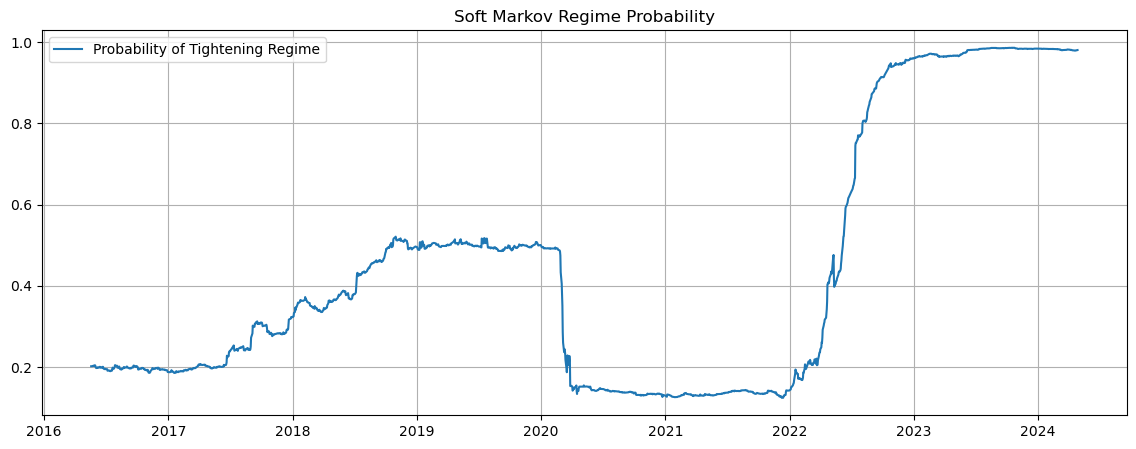


===== STARTING MS-CIR FIT =====


===== REGIME 0 PARAMETERS =====

kappa0 = 0.10173921610338788
theta0 = 0.022794348358290275
sigma0 = 0.029860766329837328

===== REGIME 1 PARAMETERS =====

kappa1 = 0.4998013100139811
theta1 = 0.030240093353230905
sigma1 = 0.050355468511034444

===== MS-CIR IN-SAMPLE R² =====

ZC050YR      : 0.9869
ZC075YR      : 0.9708
ZC100YR      : 0.9475
ZC200YR      : 0.9307
ZC500YR      : 0.8220
ZC1000YR     : 0.7206
ZC2000YR     : 0.6119
ZC3000YR     : 0.5916

===== OVERALL IN-SAMPLE R² =====

0.9114662335295078


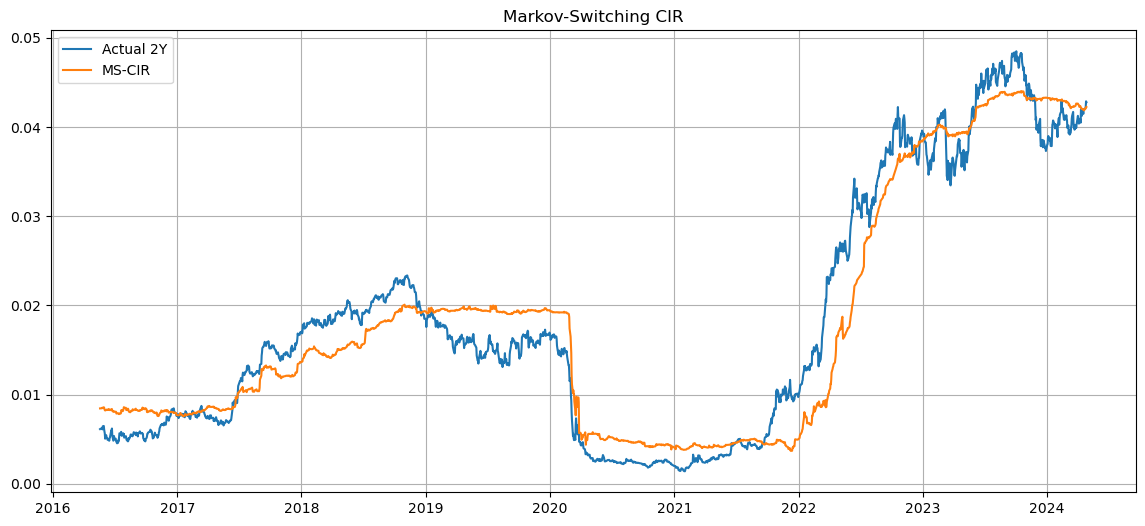

In [26]:


# =========================================================
# SHORT RATE
# =========================================================

r_short = df["ZC025YR"].values


rate_mean = np.mean(r_short)

rate_std = np.std(r_short)

zscore = (r_short - rate_mean) / rate_std

# logistic probability

p_regime1 = 1 / (1 + np.exp(-2*zscore))

# VISUALIZE REGIME PROBABILITY
# ---------------------------
plt.figure(figsize=(14,5))

plt.plot(df["Date"],p_regime1,label="Probability of Tightening Regime")

plt.title("Soft Markov Regime Probability")

plt.grid(True)

plt.legend()

plt.show()


# CIR FUNCTIONS
# ----------------------------------------------------

def gamma_cir(kappa,sigma):

    return np.sqrt(kappa**2 + 2*sigma**2)

# ---------------------------------------------------------

def B_tau(tau,kappa,sigma):

    g = gamma_cir(kappa,sigma)

    num = (2*(np.exp(g*tau)-1))

    den = ((g+kappa)*(np.exp(g*tau)-1)+2*g)

    return num / den

# ---------------------------------------------------------

def A_tau(tau,kappa,theta,sigma):

    g = gamma_cir(kappa,sigma)

    num = (2*g*np.exp((kappa+g)*tau/2))

    den = ((g+kappa)*(np.exp(g*tau)-1)+2*g)

    power = (2*kappa*theta) / (sigma**2)

    return (num / den) ** power


# SINGLE REGIME YIELD
# ----------------------------------------------------------

def cir_yield( rt,tau,kappa,theta,sigma):

    A = A_tau(tau,kappa,theta,sigma)

    B = B_tau(tau,kappa,sigma)

    P = A * np.exp(-B*rt)

    return -np.log(P) / tau


# MARKOV-SWITCHING YIELD
# -----------------------------------------------------------------

def ms_cir_yield(rt,tau,p,kappa0,theta0,sigma0,kappa1,theta1,sigma1):

    
    # REGIME 0
    # -----------------------------------

    y0 = cir_yield(rt,tau,kappa0,theta0,sigma0)

    
    # REGIME 1
    # -----------------------------------

    y1 = cir_yield(rt,tau,kappa1,theta1,sigma1)

    
    # SOFT REGIME MIXTURE
    # -----------------------------------

    y_mix = ((1-p)*y0+p*y1)

    return y_mix


# OBJECTIVE FUNCTION
# ---------------------------------------------------------

def objective(params):

    (

        kappa0,
        theta0,
        sigma0,

        kappa1,
        theta1,
        sigma1

    ) = params

    # positivity constraints

    if np.any(np.array(params) <= 0):

        return 1e10

    try:

        actual_all = []

        pred_all = []

        
        # ENTIRE CURVE
        # ---------------------------------

        for col, tau in maturity_map.items():

            actual = df[col].values

            predicted = []

            for i in range(len(df)):

                rt = r_short[i]

                p = p_regime1[i]

                y_hat = ms_cir_yield(

                    rt,
                    tau,

                    p,

                    kappa0,
                    theta0,
                    sigma0,

                    kappa1,
                    theta1,
                    sigma1

                )

                predicted.append(y_hat)

            predicted = np.array(predicted)

            actual_all.extend(actual)

            pred_all.extend(predicted)

        actual_all = np.array(actual_all)

        pred_all = np.array(pred_all)

        mse = np.mean((actual_all - pred_all)**2)

        return mse

    except:

        return 1e10


# INITIAL GUESS
# ------------------------------------------------------

initial_guess = [

    0.10,
    0.01,
    0.03,

    0.50,
    0.07,
    0.05
]

print("\n===== STARTING MS-CIR FIT =====\n")


# OPTIMIZATION
# ---------------------------------------------------

result = minimize(

    objective,

    initial_guess,

    method="L-BFGS-B",

    bounds=[

        (1e-5,5),
        (1e-5,1),
        (1e-5,1),

        (1e-5,5),
        (1e-5,1),
        (1e-5,1)

    ]

)


# OPTIMAL PARAMETERS
# ---------------------------------------

(

    kappa0_opt,
    theta0_opt,
    sigma0_opt,

    kappa1_opt,
    theta1_opt,
    sigma1_opt

) = result.x

print("\n===== REGIME 0 PARAMETERS =====\n")

print("kappa0 =", kappa0_opt)
print("theta0 =", theta0_opt)
print("sigma0 =", sigma0_opt)

print("\n===== REGIME 1 PARAMETERS =====\n")

print("kappa1 =", kappa1_opt)
print("theta1 =", theta1_opt)
print("sigma1 =", sigma1_opt)


# GENERATE FITTED CURVES
# ---------------------------------------------------------

predictions = []

for i in range(len(df)):

    rt = r_short[i]

    p = p_regime1[i]

    row = {"Date": df.loc[i, "Date"]}

    for col, tau in maturity_map.items():

        row[col] = ms_cir_yield(

            rt,
            tau,

            p,

            kappa0_opt,
            theta0_opt,
            sigma0_opt,

            kappa1_opt,
            theta1_opt,
            sigma1_opt

        )

    predictions.append(row)

pred_df = pd.DataFrame(predictions)


# IN-SAMPLE R²
# ----------------------------------------------------------------

print("\n===== MS-CIR IN-SAMPLE R² =====\n")

actual_all = []

pred_all = []

for col in maturity_map.keys():

    r2 = r2_score(df[col],pred_df[col])

    print(f"{col:<12} : {r2:.4f}")

    actual_all.extend(df[col].values)

    pred_all.extend(pred_df[col].values)

overall_r2 = r2_score(np.array(actual_all),np.array(pred_all))

print("\n===== OVERALL IN-SAMPLE R² =====\n")

print(overall_r2)


# VISUALIZATION
# ------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(df["Date"],df["ZC200YR"],label="Actual 2Y")

plt.plot(pred_df["Date"],pred_df["ZC200YR"],label="MS-CIR")

plt.legend()

plt.title("Markov-Switching CIR")

plt.grid(True)

plt.show()



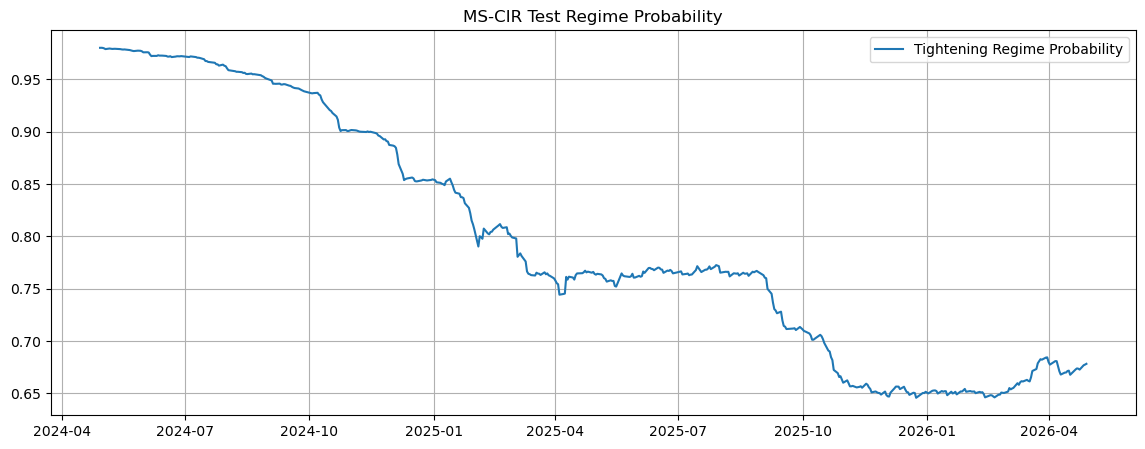


===== MS-CIR OUT-OF-SAMPLE R² =====

ZC050YR      : 0.9937
ZC075YR      : 0.9755
ZC100YR      : 0.9380
ZC200YR      : 0.6366

===== OVERALL MS-CIR OUT-OF-SAMPLE R² =====

0.9317571215912395


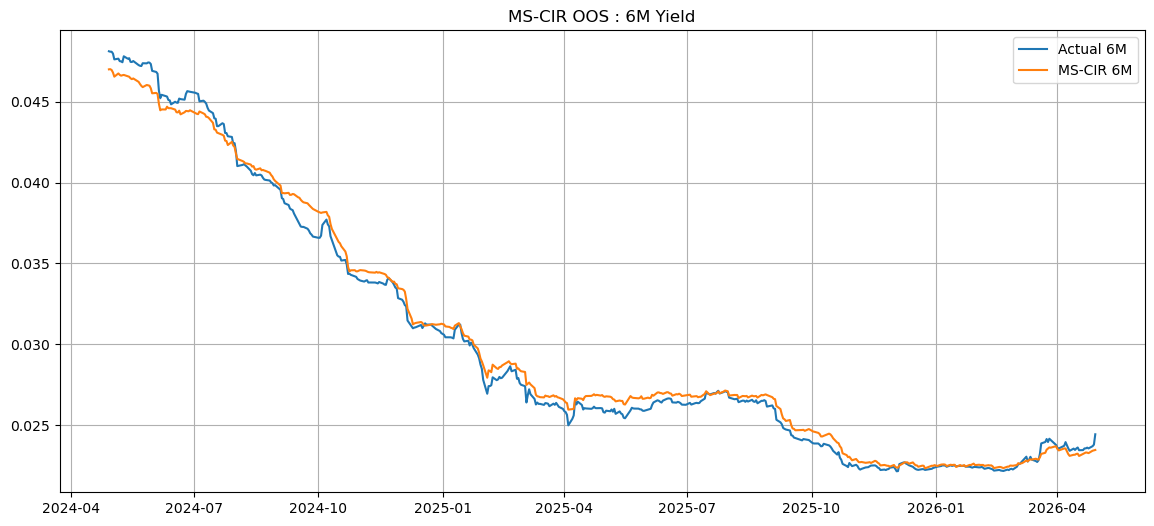

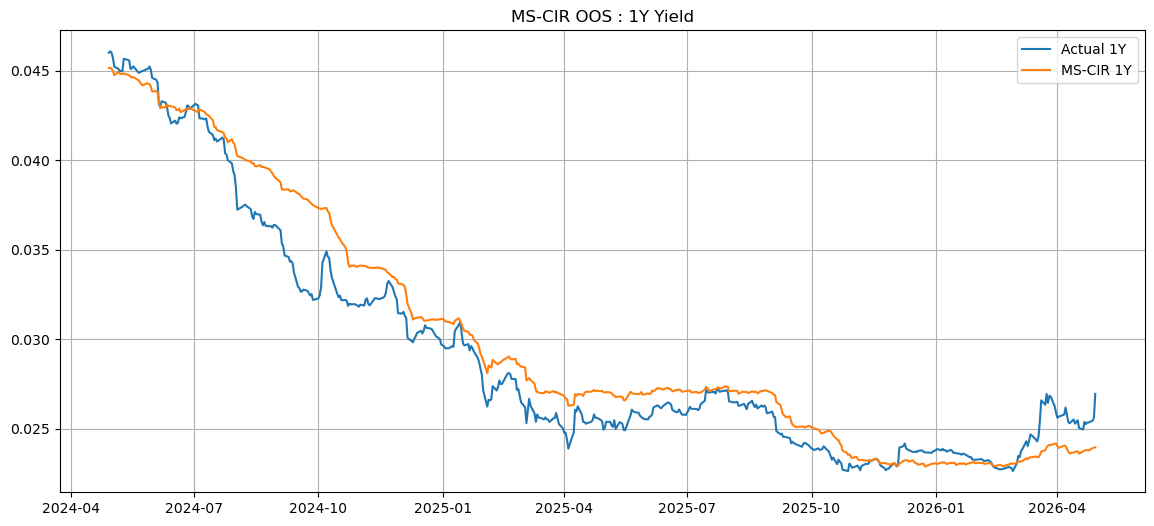

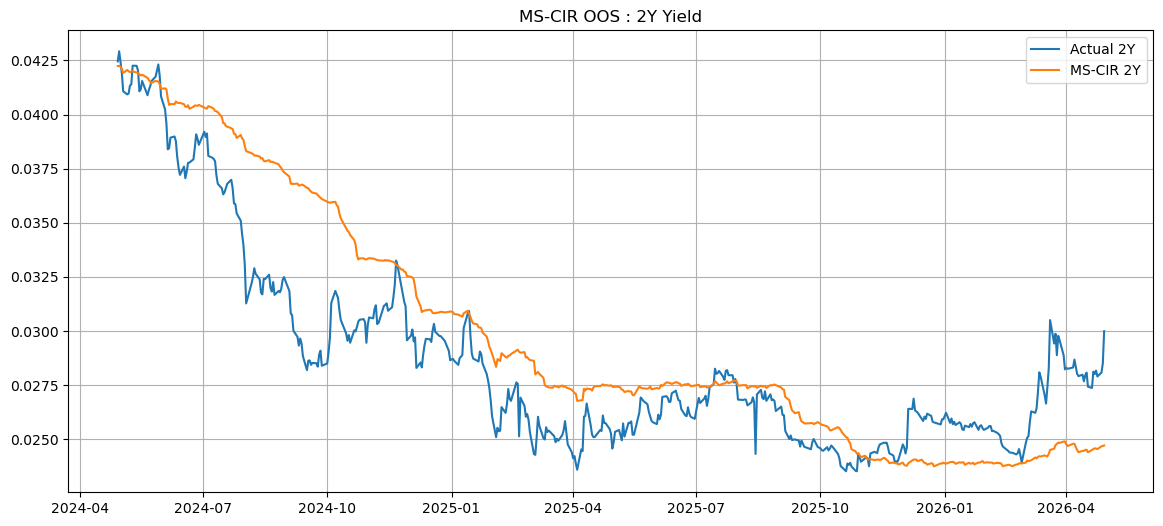

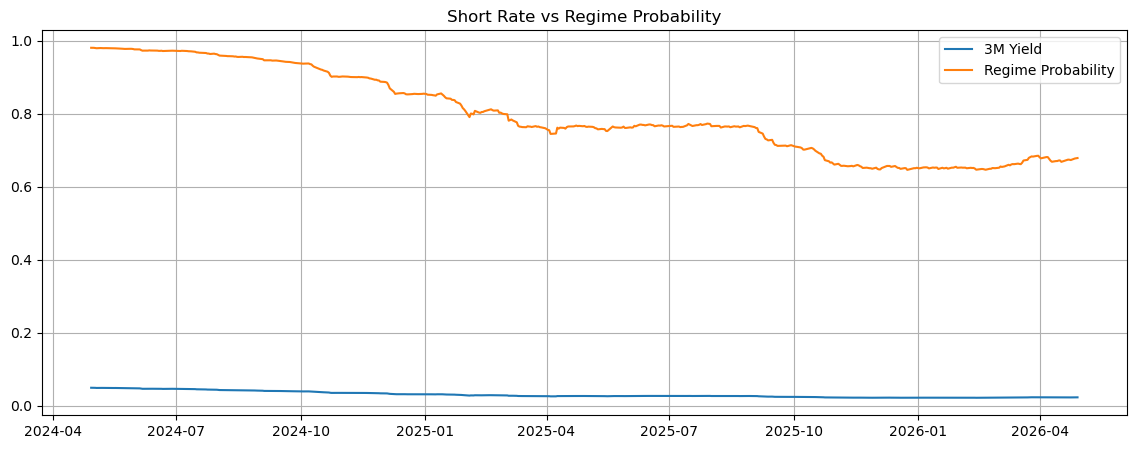

In [27]:
# MS-CIR OUT-OF-SAMPLE TESTING

# LOAD TEST DATA
# -----------------------------------------------------------------

test_curve = pd.read_csv(test_d)

test_3m = pd.read_csv(test_d3M)

# CLEAN COLUMN NAMES
# ------------------------------------------------------------

test_curve.columns = (test_curve.columns.str.strip())

test_3m.columns = (test_3m.columns.str.strip())


# DATE PARSING
# -------------------------------------------------

test_curve["Date"] = pd.to_datetime(test_curve["Date"])

test_3m["Date"] = pd.to_datetime(test_3m["Date"])


# TEST SHORT RATE
# -------------------------------------------------------

test_r_short = test_3m["ZC025YR"].values



test_zscore = (test_r_short - rate_mean) / rate_std

test_p_regime1 = 1 / (1 + np.exp(-2*test_zscore))


# VISUALIZE REGIME PROBABILITY
# --------------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(

    test_3m["Date"],

    test_p_regime1,

    label="Tightening Regime Probability"

)

plt.title(
    "MS-CIR Test Regime Probability"
)

plt.grid(True)

plt.legend()

plt.show()


# GENERATE OUT-OF-SAMPLE PREDICTIONS
#------------------------------------------------
predictions = []

for i in range(len(test_3m)):

    rt = test_r_short[i]

    p = test_p_regime1[i]

    row = {

        "Date": test_3m.loc[i, "Date"]

    }

   
    # EACH MATURITY
    # -----------------------------------------------------

    for col, tau in maturity_map.items():


        if col in test_curve.columns:

            y_hat = ms_cir_yield(

                rt,
                tau,
                p,

                # regime 0

                kappa0_opt,
                theta0_opt,
                sigma0_opt,

                # regime 1

                kappa1_opt,
                theta1_opt,
                sigma1_opt

            )

            row[col] = y_hat

    predictions.append(row)

pred_df = pd.DataFrame(predictions)


# OUT-OF-SAMPLE R²
# --------------------------------------------------

print("\n===== MS-CIR OUT-OF-SAMPLE R² =====\n")

actual_all = []

pred_all = []

for col in pred_df.columns:

    if col == "Date":
        continue

    actual = test_curve[col]

    predicted = pred_df[col]

    r2 = r2_score(actual,predicted)

    print(f"{col:<12} : {r2:.4f}")

    actual_all.extend(actual.values)

    pred_all.extend(predicted.values)


# OVERALL OUT-OF-SAMPLE R²
# ----------------------------------------------------------

overall_r2 = r2_score(np.array(actual_all),np.array(pred_all))

print("\n===== OVERALL MS-CIR OUT-OF-SAMPLE R² =====\n")

print(overall_r2)


# VISUALIZATION : 6M
# ---------------------------------------------

if "ZC050YR" in pred_df.columns:

    plt.figure(figsize=(14,6))

    plt.plot(test_curve["Date"],test_curve["ZC050YR"],label="Actual 6M")

    plt.plot(pred_df["Date"],pred_df["ZC050YR"],label="MS-CIR 6M")

    plt.legend()

    plt.title("MS-CIR OOS : 6M Yield")

    plt.grid(True)

    plt.show()


# VISUALIZATION : 1Y
# ------------------------------------------------------------------

if "ZC100YR" in pred_df.columns:

    plt.figure(figsize=(14,6))

    plt.plot(test_curve["Date"],test_curve["ZC100YR"],label="Actual 1Y")

    plt.plot(

        pred_df["Date"],

        pred_df["ZC100YR"],

        label="MS-CIR 1Y"

    )

    plt.legend()

    plt.title("MS-CIR OOS : 1Y Yield")

    plt.grid(True)

    plt.show()


# VISUALIZATION : 2Y
# =========================================================

if "ZC200YR" in pred_df.columns:

    plt.figure(figsize=(14,6))

    plt.plot(test_curve["Date"],test_curve["ZC200YR"],label="Actual 2Y")

    plt.plot(pred_df["Date"],pred_df["ZC200YR"],label="MS-CIR 2Y")

    plt.legend()

    plt.title("MS-CIR OOS : 2Y Yield")

    plt.grid(True)

    plt.show()


# COMPARE REGIME PROBABILITY VS SHORT RATE
# ------------------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(test_3m["Date"],test_r_short,label="3M Yield")

plt.plot(test_3m["Date"],test_p_regime1,label="Regime Probability")

plt.title("Short Rate vs Regime Probability")

plt.grid(True)

plt.legend()

plt.show()



### Why the Regime-Switching CIR Extension Performed Better

Several alternative extensions to the standard CIR framework were considered, including:

* CIR++
* Jump-Diffusion CIR
* Two-Factor CIR models

However, the soft regime-switching CIR extension produced the most stable and accurate yield-curve reconstruction for this dataset.

The primary reason is that the Treasury data exhibited large persistent monetary regime changes rather than isolated jumps or small curve adjustments.

The dataset contains:

* near-zero rates during 2020–2021
* sustained tightening during 2022–2024

The standard CIR model assumes a single constant parameter set

$$ (\kappa,\theta,\sigma) $$

throughout the entire sample, forcing one equilibrium level and one volatility structure across all market environments.

As a result, the base CIR model produced oversmoothed yield curves and unstable parameter estimates.

#### Why CIR++ Was Insufficient

CIR++ modifies the short rate using a deterministic shift:

$$ r_t = x_t + \phi(t) $$

This improves static curve fitting but does not adapt dynamically across changing monetary regimes because the adjustment function $ \phi(t) $ is deterministic rather than state-dependent.


#### Why Jump-Diffusion CIR Was Less Suitable

Jump-diffusion models are designed to capture abrupt discontinuous shocks:

$$ dr_t = \kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t + J_t dN_t $$

However, the dominant feature of the dataset was persistent policy regime shifts rather than isolated jumps.

Thus, adding jumps increased complexity without directly addressing the underlying structural instability.


#### Why Two-Factor Models Were Problematic

Two-factor affine models introduce additional latent factors to capture yield-curve slope and curvature dynamics.

Although mathematically more flexible, they significantly increase:

* parameter dimensionality
* calibration instability
* optimization sensitivity
* overfitting risk

Given the limited sample size and strong regime instability, multi-factor calibration became numerically unstable.

#### Why the Soft Regime-Switching CIR Worked Better

The soft regime-switching extension directly addressed the dominant feature of the data: changing monetary policy regimes.

The model allows separate CIR parameter sets for different environments:

$$ (\kappa_0,\theta_0,\sigma_0) $$

and

$$ (\kappa_1,\theta_1,\sigma_1) $$

with yields combined through:

$$ y_t=(1-p_t)y_0+p_ty_1 $$

This relaxes the strong stationarity assumption of the standard CIR model.

# Final Results
The final in-sample reconstruction accuracy was:

$$ R^2_{\text{in-sample}} = 0.9115 $$

The model achieved particularly strong performance for short and medium maturities:

6M: $R^2 = 0.9869$
9M: $R^2 = 0.9708$
1Y: $R^2 = 0.9475$
2Y: $R^2 = 0.9307$

Performance gradually declined for longer maturities:

5Y: $R^2 = 0.8220$
10Y: $R^2 = 0.7206$
20Y: $R^2 = 0.6119$
30Y: $R^2 = 0.5916$

This indicates that the regime-switching extension significantly improved the model’s ability to capture short- and medium-term monetary policy dynamics, although long-end yield reconstruction remains challenging due to additional macroeconomic factors not captured by a one-factor framework.

Out-of-Sample Performance

The model also generalized well out-of-sample, achieving:

### $$ R^2_{\text{out-of-sample}} = 0.9318 $$

The out-of-sample maturity-wise performance was:

6M: $R^2 = 0.9937$
9M: $R^2 = 0.9755$
1Y: $R^2 = 0.9380$
2Y: $R^2 = 0.6366$

The strong out-of-sample performance suggests that the regime-switching extension improved model flexibility without severe overfitting.

Compared with the standard CIR model, the soft regime framework adapted more effectively to changing monetary environments by allowing different parameter sets for low-rate and tightening regimes.

The extension therefore reduced the structural instability observed under the single-regime CIR calibration and produced a more stable reconstruction of yield curve